In [1]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn  
import optuna
from sklearn.linear_model import LinearRegression, Ridge
import lightgbm as lgb
sys.path.append("..")
import importlib, src.models
importlib.reload(src.models)

from src.metrics import evaluate,regression_scores
from src.models import make_pipe,make_preprocessor,make_lgbm_l1_objective,load_run_model
from sklearn.metrics import mean_absolute_error

# Modeling

Third notebook in the pipeline: **EDA → Feature Engineering → Modeling**.

We load the engineered dataset and run a **model ladder** — Stage 0 baselines → Stage 1 linear (OLS, Ridge) → Stage 2 LightGBM — predicting arrival delay **before departure**. Models are scored with **MAE** (primary) and **RMSE** on the time-ordered **validation** split; the **test** split is held out for a single final number. Every target-based transform (encoders, the outlier cap) is fit on **train only**, and runs are tracked with **MLflow**.

## Load the engineered data & recover the split

Load `flights_features.parquet` and slice it into `train` / `val` / `test` using the `split` label from feature engineering. Two targets ride along: models **train on `arr_delay_capped`** (winsorized at the train 99th percentile) but are **scored on the true `arr_delay`** for an honest val/test error.

In [2]:
DATA = Path("../data/processed")
flights = pd.read_parquet(DATA / "flights_features.parquet")

train = flights[flights["split"] == "train"]
val   = flights[flights["split"] == "val"]
test  = flights[flights["split"] == "test"]

for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:5} {len(part):>9,}  {part['fl_date'].min().date()} -> {part['fl_date'].max().date()}")
flights.shape

train 4,875,686  2024-01-01 -> 2024-09-14
val     696,527  2024-09-14 -> 2024-10-19
test  1,393,054  2024-10-19 -> 2024-12-31


(6965267, 28)

## Stage 0 — baselines (the numbers to beat)

Every model must beat two trivial predictors, scored on the **real** `arr_delay` (val):

- **Constant** — one number for every flight. The MAE-optimal constant is the **median**, the RMSE-optimal is the **mean**, so we show both.
- **Group mean** — the average (capped) delay for each `(carrier, dep_hour)` slot, learned on **train**. A strong non-parametric benchmark: if a model can't beat "just memorise the average for this carrier-and-hour," it isn't learning.

(These use the `evaluate` helper from `src/metrics.py` so every score is computed identically.)

In [3]:
results = []
y_val = val["arr_delay"].to_numpy()          


evaluate("mean",   y_val, np.full(len(val), train["arr_delay_capped"].mean()),   results)
evaluate("median", y_val, np.full(len(val), train["arr_delay_capped"].median()), results)


grp = ["op_unique_carrier", "dep_hour"]
global_mean = train["arr_delay_capped"].mean()
gm = (train.groupby(grp, observed=True)["arr_delay_capped"].mean()
           .rename("pred").reset_index())
pred_grp = val[grp].merge(gm, on=grp, how="left")["pred"].fillna(global_mean).to_numpy()
evaluate("(carrier, dep_hour) mean", y_val, pred_grp, results)

pd.DataFrame(results).set_index("model").round(2)

mean                       MAE  23.52   RMSE  45.78   R2 -0.021
median                     MAE  18.54   RMSE  45.67   R2 -0.016
(carrier, dep_hour) mean   MAE  23.10   RMSE  45.68   R2 -0.017


,MAE,RMSE,R2
model,,,
mean,23.52,45.78,-0.02
median,18.54,45.67,-0.02
"(carrier, dep_hour) mean",23.10,45.68,-0.02


## Stage 1 — linear models (OLS & Ridge)

The first *learned* models. Linear regression needs numeric inputs, so we fit a preprocessing pipeline **on train**:

- **Categoricals** (`carrier`, `origin`, `dest`, `season`) → **target encoding** (sklearn `TargetEncoder`, cross-fitted on train to avoid leakage): each level becomes its mean (capped) delay, collapsing high cardinality to a single column.
- **Numeric + cyclical** (`distance`, `departures_in_hour`, `is_weekend`, the sin/cos features) → **standardized** (zero mean, unit variance) so the penalty treats them evenly.

**The math.** With design matrix $X$ (rows = flights, columns = features) and target $y$, ordinary least squares picks the coefficients $\beta$ minimising the squared error:

$$\hat{\beta}_{\text{OLS}} = \arg\min_{\beta}\ \lVert y - X\beta \rVert_2^2 = (X^\top X)^{-1} X^\top y.$$

**Ridge** adds an L2 penalty $\alpha\lVert\beta\rVert_2^2$ that shrinks the coefficients — it stabilises the fit when features are correlated (our encodings are) and trades a little bias for lower variance:

$$\hat{\beta}_{\text{Ridge}} = \arg\min_{\beta}\ \lVert y - X\beta \rVert_2^2 + \alpha\lVert\beta\rVert_2^2 = (X^\top X + \alpha I)^{-1} X^\top y.$$

Both fit the **capped** target and are scored on the **real** `arr_delay`.

*(`op_carrier_fl_num`, the flight-number identifier, is left out of these models — ~thousands of levels with a stray null.)*

In [4]:


mlflow.set_experiment("flight-delay-before-departure")

cat_cols = ["op_unique_carrier", "origin", "dest", "season"]
num_cols = ["distance", "departures_in_hour", "is_weekend",
            "dep_hour_sin", "dep_hour_cos",
            "day_of_week_sin", "day_of_week_cos",
            "day_of_month_sin", "day_of_month_cos"]

X_train, y_train = train[cat_cols + num_cols], train["arr_delay_capped"]
X_val = val[cat_cols + num_cols]

for name, model in [("OLS", LinearRegression()), ("Ridge", Ridge(alpha=10.0))]:
    with mlflow.start_run(run_name=name):
        pipe = make_pipe(model, num_cols, cat_cols).fit(X_train, y_train)
        scores = evaluate(name, y_val, pipe.predict(X_val), results)
        mlflow.log_params({"model": name, "n_features": len(cat_cols + num_cols),
                           "target": "arr_delay_capped", **model.get_params()})
        mlflow.log_metrics({f"val_{k}": v for k, v in scores.items()})
        mlflow.sklearn.log_model(pipe, name="model")    

pd.DataFrame(results).set_index("model").round(2)

OLS                        MAE  19.76   RMSE  45.28   R2  0.001
Ridge                      MAE  19.76   RMSE  45.28   R2  0.001


,MAE,RMSE,R2
model,,,
mean,23.52,45.78,-0.02
median,18.54,45.67,-0.02
"(carrier, dep_hour) mean",23.10,45.68,-0.02
OLS,19.76,45.28,0.00
Ridge,19.76,45.28,0.00


### Tuning Ridge — `alpha` sweep on validation

Ridge's one hyperparameter is the L2 strength `alpha`. We tune it by sweeping a log-spaced range and scoring each on **val** (test stays untouched). For speed we **fit the target-encoding once** (via `make_preprocessor` — it's the expensive step and is `alpha`-independent) and then refit only the cheap Ridge solve per value.

With ~4.9 M rows and ~13 features ($n \gg p$) we expect `alpha` to barely move the needle until it's large enough to over-shrink the coefficients — worth *showing* rather than assuming.

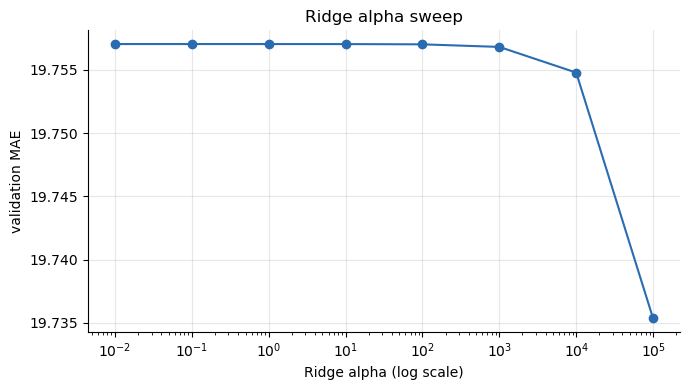

,MAE,RMSE,R2
alpha,,,
0.01,19.757,45.280,0.001
0.10,19.757,45.280,0.001
1.00,19.757,45.280,0.001
10.00,19.757,45.280,0.001
100.00,19.757,45.280,0.001
1000.00,19.757,45.280,0.001
10000.00,19.755,45.279,0.001
100000.00,19.735,45.272,0.001


In [13]:
pre = make_preprocessor(num_cols, cat_cols)
Xtr = pre.fit_transform(X_train, y_train)   
Xva = pre.transform(X_val)                  

alphas = [0.01, 0.1, 1, 10, 100, 1_000, 10_000, 100_000]
sweep = pd.DataFrame(
    [{"alpha": a, **regression_scores(y_val, Ridge(alpha=a).fit(Xtr, y_train).predict(Xva))}
     for a in alphas]
).set_index("alpha")

ax = sweep["MAE"].plot(logx=True, marker="o", figsize=(7, 4), color="#2b6cb0")
ax.set(xlabel="Ridge alpha (log scale)", ylabel="validation MAE", title="Ridge alpha sweep")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
sweep.round(3)

## Conclusion — the linear stage

The linear family is fully explored, and each fit is saved as an **MLflow** run (params, val metrics, and the pipeline itself). Summary (validation, scored on the real `arr_delay`):

| model | MAE | RMSE | R² |
|---|---|---|---|
| median baseline | **18.54** | 45.67 | ≈ 0 |
| mean baseline | 23.52 | 45.78 | ≈ 0 |
| **OLS** | 19.76 | 45.28 | 0.001 |
| **Ridge** (any α) | 19.76 | 45.28 | 0.001 |

Three honest conclusions:

1. **Near-zero R².** The pre-departure schedule explains almost none of arrival delay's *variance*. Mechanistically this points at the **information available**, not the model: the day-of drivers of delay (weather, congestion, cascading late aircraft) aren't in the schedule at all. Stage 2 and the after-departure benchmark below probe how far that holds.
2. **OLS/Ridge beat the *mean* baselines but not the *median*.** Trained on squared error, they predict the conditional **mean**, which on a right-skewed target sits above the median — the wrong target for MAE. The features clearly add signal (19.76 < 23.5), but the objective fights the metric.
3. **Regularisation is inert.** With $n \gg p$ (~4.9M rows, ~13 features) there is nothing to overfit, so `alpha` barely moves MAE across seven orders of magnitude.

**Where this points:** to win on MAE we need a model that predicts the **median** and can exploit non-linear interactions — i.e. **gradient-boosted trees with an L1 loss** (Stage 2). The linear model's flat, near-zero-R² verdict is also what motivates the after-departure **benchmark** below: how much does the day-of departure state add that the schedule cannot?

## Stage 2 — LightGBM (gradient-boosted trees)

The workhorse of tabular ML — here it is in depth.

### Gradient boosting

We build an **additive ensemble** of shallow regression trees, added one at a time:

$$F_M(x) = \sum_{m=1}^{M} \nu\, h_m(x),$$

where each $h_m$ is a tree and $\nu \in (0,1]$ is the **learning rate** (shrinkage). Boosting is **gradient descent in function space**: given $F_{m-1}$, we add the tree that most reduces the loss $L(y,F)$. The steepest-descent direction at each training point is the negative gradient — the **pseudo-residual**

$$r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F = F_{m-1}},$$

and $h_m$ is a regression tree fit to $\{(x_i,\, r_{im})\}$.

**Why the loss choice decides what a leaf predicts:**
- Squared loss $L=\tfrac12(y-F)^2$ gives $r_{im}=y_i-F_{m-1}(x_i)$ (ordinary residuals) and each leaf's optimal value is the **mean** of its residuals.
- Our **L1 loss** $L=\lvert y-F\rvert$ gives $r_{im}=\operatorname{sign}\!\big(y_i-F_{m-1}(x_i)\big)\in\{-1,+1\}$ — only *which side* of the current prediction a point is on — and each leaf's optimal value is the **median**. That is exactly why `objective="regression_l1"` predicts the conditional median, the MAE-optimal target OLS could not reach.

### Choosing each tree and its splits

LightGBM (like XGBoost) uses a **second-order** approximation of the loss around $F_{m-1}$ with gradients $g_i$ and Hessians $h_i$, plus a regularizer $\Omega(h_m)=\gamma T + \tfrac12\lambda\sum_j w_j^2$ over $T$ leaves with weights $w_j$:

$$\tilde{L}^{(m)} \approx \sum_i \Big(g_i\, h_m(x_i) + \tfrac12 h_i\, h_m(x_i)^2\Big) + \Omega(h_m).$$

For a fixed structure the optimal leaf weight and the **gain** of a candidate split are

$$w_j^{*} = -\frac{\sum_{i\in j} g_i}{\sum_{i\in j} h_i + \lambda}, \qquad
\mathrm{Gain} = \tfrac12\!\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right] - \gamma,$$

with $G,H$ the summed gradients/Hessians in each child. The tree greedily takes the split of largest gain.

### What makes LightGBM fast *and* accurate

- **Histogram split-finding** — continuous features are bucketed into ~255 bins, so evaluating splits costs $O(\#\text{bins})$ not $O(\#\text{rows})$: the reason it scales to millions of flights.
- **Leaf-wise growth** — it grows the leaf of largest gain next (best-first) rather than level-by-level, giving deeper, more expressive trees for a given `num_leaves` (at some overfitting risk — hence tuning).
- **Native categoricals** — it partitions category values directly (ordered by target statistics), avoiding a one-hot blow-up for our carriers and airports.
- **Shrinkage & early stopping** — each tree is scaled by $\nu$ (smaller $\nu$ ⇒ more, gentler trees); we allow up to 2000 trees but **stop when validation L1 plateaus**, tuning the effective count for free.

Trees take the **raw** temporals + native categoricals (no cyclical / scaling) — trained on the capped target, scored on the real `arr_delay`, and logged to MLflow.

In [6]:
import mlflow.lightgbm

tree_num = ["month", "day_of_month", "day_of_week", "dep_hour",
            "distance", "departures_in_hour", "is_weekend"]
tree_cat = ["op_unique_carrier", "origin", "dest"]
feat = tree_num + tree_cat

Xtr = train[feat].copy()
Xva = val[feat].copy()
for c in tree_cat:                       
    Xtr[c] = Xtr[c].astype("category")
    Xva[c] = Xva[c].astype("category")

params = dict(objective="regression_l1", n_estimators=2000, learning_rate=0.05,
              num_leaves=63, n_jobs=-1, verbose=-1)

with mlflow.start_run(run_name="LightGBM"):
    lgbm = lgb.LGBMRegressor(**params)
    lgbm.fit(Xtr, train["arr_delay"],
             eval_set=[(Xva, val["arr_delay"])], eval_metric="l1",
             callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    scores = evaluate("LightGBM", y_val, lgbm.predict(Xva), results)
    mlflow.log_params({**params, "best_iteration": lgbm.best_iteration_, "n_features": len(feat)})
    mlflow.log_metrics({f"val_{k}": v for k, v in scores.items()})
    mlflow.lightgbm.log_model(lgbm, name="model")

print(f"stopped at {lgbm.best_iteration_} trees")
pd.DataFrame(results).set_index("model").round(2)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[78]	valid_0's l1: 17.9661
LightGBM                   MAE  17.97   RMSE  45.88   R2 -0.026
stopped at 78 trees


,MAE,RMSE,R2
model,,,
mean,23.52,45.78,-0.02
median,18.54,45.67,-0.02
"(carrier, dep_hour) mean",23.10,45.68,-0.02
OLS,19.76,45.28,0.00
Ridge,19.76,45.28,0.00
LightGBM,17.97,45.88,-0.03


## Tuning LightGBM — Optuna (Bayesian optimization) on validation

### The problem
Hyperparameter tuning is itself an optimization: we seek

$$\boldsymbol{\lambda}^{*} = \arg\min_{\boldsymbol{\lambda}\in\Lambda}\ \mathcal{L}_{\text{val}}(\boldsymbol{\lambda}),$$

where $\boldsymbol{\lambda}$ is a configuration (`learning_rate`, `num_leaves`, `min_child_samples`, ...) and $\mathcal{L}_{\text{val}}$ is the **validation MAE** of a LightGBM trained with $\boldsymbol{\lambda}$. This objective is a **black box** — expensive (train a model per evaluation), non-differentiable, and noisy. Grid search is exponential in the number of knobs; random search never uses what it has already seen.

### Optuna and the TPE sampler
**Optuna** runs a *study* made of *trials*; each trial's `objective` suggests a $\boldsymbol{\lambda}$, trains, and returns the score. Its default sampler is the **Tree-structured Parzen Estimator (TPE)**, a form of **Bayesian optimization**. After a few trials, TPE splits the observed configurations by a score quantile into "good" and "bad" and fits two densities over the hyperparameter space:

$$p(\boldsymbol{\lambda}\mid \text{score}) = \begin{cases}\ell(\boldsymbol{\lambda}) & \text{score} < y^{*}\ \ (\text{good})\\[2pt] g(\boldsymbol{\lambda}) & \text{otherwise}\ \ (\text{bad}).\end{cases}$$

The **Expected Improvement** acquisition can be shown to satisfy

$$\mathrm{EI}(\boldsymbol{\lambda}) \;\propto\; \Big(\gamma + (1-\gamma)\,\tfrac{g(\boldsymbol{\lambda})}{\ell(\boldsymbol{\lambda})}\Big)^{-1},$$

so maximising it is equivalent to **maximising the ratio $\ell(\boldsymbol{\lambda})/g(\boldsymbol{\lambda})$** — propose the next configuration where "good" configs are dense and "bad" ones are sparse. TPE therefore **learns where the promising region is** and concentrates trials there, needing far fewer evaluations than grid or random search.

### Our setup
Each trial trains LightGBM on a **1M-row train subsample** (for speed) with early stopping on val, returning val MAE; the study minimises it over 25 trials; the winning $\boldsymbol{\lambda}^{*}$ is then **refit on the full train set**. Given the near-zero-R² ceiling, expect a **modest** gain — the value here is a principled, reproducible search. *(Needs `pip install optuna`; ~10–20 min.)*

In [7]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

samp = train.sample(n=1_000_000, random_state=0)
Xs = samp[feat].copy()
ys = samp["arr_delay"]
for c in tree_cat:
    Xs[c] = Xs[c].astype("category")

objective = make_lgbm_l1_objective(Xs, ys, Xva, y_val, y_val)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=25, show_progress_bar=True)
print("best val MAE:", round(study.best_value, 3))
study.best_params


  0%|          | 0/25 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[139]	valid_0's l1: 17.9241
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[118]	valid_0's l1: 17.9247
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[396]	valid_0's l1: 17.8608
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[94]	valid_0's l1: 17.9025
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[108]	valid_0's l1: 17.9428
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[216]	valid_0's l1: 17.8946
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[43]	valid_0's l1: 17.9438
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[52]	valid_0's l1: 17.9386
Training un

{'learning_rate': 0.02059041904426823,
 'num_leaves': 182,
 'min_child_samples': 368,
 'feature_fraction': 0.6036418732082208,
 'subsample': 0.6521258464105091}

In [8]:
best = dict(objective="regression_l1", n_estimators=2000, n_jobs=-1, verbose=-1,
            subsample_freq=1, **study.best_params)

with mlflow.start_run(run_name="LightGBM (tuned)"):
    lgbm_t = lgb.LGBMRegressor(**best).fit(
        Xtr, train["arr_delay"], eval_set=[(Xva, val["arr_delay"])], eval_metric="l1",
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    scores = evaluate("LightGBM (tuned)", y_val, lgbm_t.predict(Xva), results)
    mlflow.log_params({**best, "best_iteration": lgbm_t.best_iteration_})
    mlflow.log_metrics({f"val_{k}": v for k, v in scores.items()})
    mlflow.lightgbm.log_model(lgbm_t, name="model")

print(f"tuned model stopped at {lgbm_t.best_iteration_} trees")
pd.DataFrame(results).set_index("model").round(2)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[447]	valid_0's l1: 17.8182
LightGBM (tuned)           MAE  17.82   RMSE  45.76   R2 -0.021
tuned model stopped at 447 trees


,MAE,RMSE,R2
model,,,
mean,23.52,45.78,-0.02
median,18.54,45.67,-0.02
"(carrier, dep_hour) mean",23.10,45.68,-0.02
OLS,19.76,45.28,0.00
Ridge,19.76,45.28,0.00
LightGBM,17.97,45.88,-0.03
LightGBM (tuned),17.82,45.76,-0.02


# How much does departure-time information add? An after-departure benchmark

Stage 2 hit a wall: even a tuned gradient-boosted ensemble beats the median by **under a minute**, with R² ≈ 0. Rather than *conclude* from that alone, we ask a sharper, answerable question: **how much does the picture change the moment the flight actually departs?**

So we run a **control experiment** — give the *same* LightGBM the one thing we withheld as leakage, **how the flight actually left** (`dep_delay`, `taxi_out`, `wheels_off`), and measure how predictable arrival delay becomes. This is a **benchmark, not a proof**: it quantifies the *value of departure-time information*, and confirms the pipeline can extract signal *when signal is present* — so a weak before-departure score is at least not the model being fundamentally incapable. It does **not**, by itself, show the schedule holds *no* signal; it measures how large the gap is between what is knowable before departure and at departure.

### Why the departure state is (almost) the whole answer

Arrival delay decomposes **exactly** (gate-to-gate, ignoring the midnight wrap):

$$\text{arr\_delay} \;=\; \underbrace{(\text{dep\_time}-\text{crs\_dep\_time})}_{\text{dep\_delay}} \;+\; \underbrace{(\text{actual\_elapsed}-\text{crs\_elapsed})}_{\Delta_{\text{enroute}}},$$

because $\text{arr\_delay}=\text{arr\_time}-\text{crs\_arr\_time}$ and $\text{arr\_time}=\text{dep\_time}+\text{actual\_elapsed}$. Once a flight has pushed back, its arrival delay is therefore **already determined up to the enroute term** $\Delta_{\text{enroute}}$ — the deviation of taxi + air time from the scheduled block. Airlines pad block times, so $\Delta_{\text{enroute}}$ is comparatively low-variance and often *negative* (crews make up time in the air). This is exactly why `dep_delay` alone tracks `arr_delay` with R² ≈ 0.9 in the EDA: the identity above is dominated by its first term.

### The experiment

We rebuild the **same** time-ordered train/val/test split from `flights_clean.parquet`, add the **post-departure** state a controller would know once the aircraft is moving — `dep_delay`, `taxi_out`, and `wheels_off` — and retrain the **identical** LightGBM (`regression_l1`, same features + these three). Everything else is held fixed, so any change in MAE is attributable to the *information*, not the model.

We deliberately **exclude** the BTS cause-code buckets (`carrier_delay`, `nas_delay`, `weather_delay`, `late_aircraft_delay`): those are a *post-arrival accounting decomposition of the delay itself*, so feeding them back is tautological, not prediction. `dep_delay`/`taxi_out`/`wheels_off` are genuine upstream states observed *before* arrival.

> ⚠️ **Diagnostic only.** This model uses information unavailable at scheduling time and is **not** a deployable before-departure predictor. Its job is to benchmark how much departure-time information is worth, not to serve as a forecast. Its numbers are interpreted *below*, after the cell runs.


In [9]:
key   = ["fl_date", "op_unique_carrier", "op_carrier_fl_num", "origin", "dest", "crs_dep_time"]
extra = ["dep_delay", "taxi_out", "wheels_off"]
clean_extra = pd.read_parquet(DATA / "flights_clean.parquet", columns=key + extra)

before = len(flights)
flights_ad = flights.merge(clean_extra, on=key, how="left")   
assert len(flights_ad) == before, "merge changed the row count -> flight key is not unique"
print(f"merged {len(flights_ad):,} rows | new-column nulls: {flights_ad[extra].isna().sum().to_dict()}")

train_ad = flights_ad[flights_ad["split"] == "train"]
val_ad   = flights_ad[flights_ad["split"] == "val"]

feat_ad     = feat + extra
y_train_ad  = train_ad["arr_delay"]
y_val_ad    = val_ad["arr_delay"].to_numpy()
Xtr_ad = train_ad[feat_ad].copy()
Xva_ad = val_ad[feat_ad].copy()
for c in tree_cat:
    Xtr_ad[c] = Xtr_ad[c].astype("category")
    Xva_ad[c] = Xva_ad[c].astype("category")
print("features:", feat_ad)


merged 6,965,267 rows | new-column nulls: {'dep_delay': 0, 'taxi_out': 0, 'wheels_off': 0}
features: ['month', 'day_of_month', 'day_of_week', 'dep_hour', 'distance', 'departures_in_hour', 'is_weekend', 'op_unique_carrier', 'origin', 'dest', 'dep_delay', 'taxi_out', 'wheels_off']


In [10]:

samp_ad = train_ad.sample(n=1_000_000, random_state=0)
Xs_ad = samp_ad[feat_ad].copy()
ys_ad = samp_ad["arr_delay"]
for c in tree_cat:
    Xs_ad[c] = Xs_ad[c].astype("category")

objective_ad = make_lgbm_l1_objective(Xs_ad, ys_ad, Xva_ad, y_val_ad, y_val_ad)

study_ad = optuna.create_study(direction="minimize")
study_ad.optimize(objective_ad, n_trials=25, show_progress_bar=True)
print("best val MAE:", round(study_ad.best_value, 3))
study_ad.best_params


  0%|          | 0/25 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[837]	valid_0's l1: 6.61897
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1026]	valid_0's l1: 6.60008
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1837]	valid_0's l1: 6.58284
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1873]	valid_0's l1: 6.5903
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1976]	valid_0's l1: 6.56836
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[465]	valid_0's l1: 6.626
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[805]	valid_0's l1: 6.71385
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1993]	va

{'learning_rate': 0.02384700134734829,
 'num_leaves': 226,
 'min_child_samples': 89,
 'feature_fraction': 0.8310033837426722,
 'subsample': 0.7367541996740016}

In [11]:
best_ad = dict(objective="regression_l1", n_estimators=2000, n_jobs=-1, verbose=-1,
               subsample_freq=1, **study_ad.best_params)

mlflow.set_experiment("flight-delay-DIAGNOSTIC")
with mlflow.start_run(run_name="LightGBM after-departure (diagnostic)"):
    lgbm_ad = lgb.LGBMRegressor(**best_ad).fit(
        Xtr_ad, y_train_ad, eval_set=[(Xva_ad, y_val_ad)], eval_metric="l1",
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    scores = evaluate("LightGBM after-departure (diag.)", y_val_ad, lgbm_ad.predict(Xva_ad), results)
    mlflow.log_params({**best_ad, "best_iteration": lgbm_ad.best_iteration_,
                       "features": ",".join(feat_ad),
                       "WARNING": "diagnostic - uses post-departure info, not deployable"})
    mlflow.log_metrics({f"val_{k}": v for k, v in scores.items()})
    mlflow.lightgbm.log_model(lgbm_ad, name="model")

print(f"after-departure model stopped at {lgbm_ad.best_iteration_} trees")
pd.DataFrame(results).set_index("model").round(2)


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 6.44861
LightGBM after-departure (diag.) MAE   6.45   RMSE   9.73   R2  0.954
after-departure model stopped at 2000 trees


,MAE,RMSE,R2
model,,,
mean,23.52,45.78,-0.02
median,18.54,45.67,-0.02
"(carrier, dep_hour) mean",23.10,45.68,-0.02
OLS,19.76,45.28,0.00
Ridge,19.76,45.28,0.00
LightGBM,17.97,45.88,-0.03
LightGBM (tuned),17.82,45.76,-0.02
LightGBM after-departure (diag.),6.45,9.73,0.95


## Conclusion — how predictable arrival delay is once the flight departs

Given three post-departure columns, the *identical* model, split, and tuning procedure predicts arrival delay almost perfectly:

| setting | features | MAE | RMSE | R² |
|---|---|---|---|---|
| **Before departure** (tuned) | schedule only | 17.82 | 45.76 | −0.02 |
| **After departure** (tuned, *diagnostic*) | schedule **+ dep_delay, taxi_out, wheels_off** | **6.45** | **9.73** | **0.954** |

MAE drops **64%** (17.82 → 6.45 min), RMSE **79%** (45.76 → 9.73), R² **≈ 0 → 0.95**. This is not a smarter model — it is the same LightGBM handed information the schedule never contained, and it is *easy* information: the identity $\text{arr\_delay}=\text{dep\_delay}+\Delta_{\text{enroute}}$ means arrival delay is nearly **locked in at pushback**, so once departure is observed the prediction is almost mechanical — **RMSE ≈ 9.7 min is essentially the leftover block-time (taxi + air) variance.**

**What this does — and does not — show:**

- **How much departure-time information is worth.** The 11.4-minute MAE gap (17.82 → 6.45) is the value of knowing how a flight actually left — a benchmark for a day-of state that is simply unavailable at scheduling time.
- **That the pipeline is capable.** The same model that plateaued before departure reaches R² 0.95 here, so the weak before-departure score is *not* the model being fundamentally unable to learn delay.
- **It does *not* prove the schedule is signal-free.** A high after-departure score cannot establish a *negative* about the pre-departure features — better features (say, weather forecasts) might extract a little more. The case that the before-departure ceiling is intrinsic rests instead on **mechanism**: the known drivers of delay — weather, ATC ground stops, cascading late aircraft (the BTS cause codes) — are *day-of realized events*, absent from the published schedule by construction. The after-departure jump is *consistent* with that, not a proof of it.
- **A diagnostic, not a product.** `dep_delay`/`taxi_out`/`wheels_off` are unknown at scheduling time; this model can't serve the before-departure task.
- **Trained on the real target.** These trees train on the *uncapped* `arr_delay`. Winsorizing (which we keep for the squared-loss linear stage) would clip the model's predictions in exactly the high-`dep_delay` groups where the conditional median exceeds the cap — a flight that left five hours late arrives ~five hours late — so capping here would forbid the large-but-**predictable** delays the model can clearly resolve. An L1 loss is already robust to the tail, so keeping them costs nothing.

**One-line takeaway.** Once a flight has left, its arrival delay is *easy* to predict — MAE ~6.5 min, R² 0.95 — because it is nearly determined by departure delay; *before* it leaves, the same effort yields ~18 min, because the day-of causes have not happened yet. This benchmark measures that gap; it does not, by itself, prove the schedule is barren.


## Final evaluation — the untouched test split

Everything so far was tuned and compared on **validation**; the **test** split (the last ~20%, mid-Oct → Dec 2024) has never been touched. We spend it **once** — and rather than refit, we **load each logged model back from MLflow** (`load_run_model` in `src/models.py`) and score it on test. This exercises the full MLflow lifecycle (**log → load → predict**) and guarantees we evaluate the *same* artifacts we selected on validation.

We carry the **whole ladder** through to test, so nothing is cherry-picked:
- **Naive (median)** — the constant baseline every model must beat;
- **Ridge** — the tuned linear model (loaded from MLflow, *sklearn* flavor);
- **Before departure** — the *deployable* LightGBM (schedule only), our answer to the stated problem;
- **After departure** — the *diagnostic* LightGBM (+ `dep_delay` / `taxi_out` / `wheels_off`), so the information ceiling shows on held-out data too.

Each model's **test vs. validation** gap is the check that tuning **generalised** ($\text{test}\approx\text{val}\Rightarrow$ no validation overfitting). *(Interpretation written below, after the cell runs.)*


In [12]:

test = flights[flights["split"] == "test"]
y_te = test["arr_delay"].to_numpy()


Xte     = test[feat].copy()                                          
Xte_ad  = flights_ad[flights_ad["split"] == "test"][feat_ad].copy() 
for c in tree_cat:
    Xte[c]    = Xte[c].astype("category")
    Xte_ad[c] = Xte_ad[c].astype("category")
Xte_lin = test[cat_cols + num_cols]                                  


ridge = load_run_model("flight-delay-before-departure", "Ridge",            flavor="sklearn")
bd    = load_run_model("flight-delay-before-departure", "LightGBM (tuned)", flavor="lightgbm")
ad    = load_run_model("flight-delay-DIAGNOSTIC", "LightGBM after-departure (diagnostic)", flavor="lightgbm")


naive_pred = np.full(len(test), train["arr_delay"].median())  
test_results = []
evaluate("Naive (median)",                y_te, naive_pred,            test_results)
evaluate("Ridge (test)",                  y_te, ridge.predict(Xte_lin), test_results)
evaluate("Before-departure (test)",       y_te, bd.predict(Xte),       test_results)
evaluate("After-departure (test, diag.)", y_te, ad.predict(Xte_ad),    test_results)
pd.DataFrame(test_results).set_index("model").round(2)


Naive (median)             MAE  20.87   RMSE  51.44   R2 -0.021
Ridge (test)               MAE  22.52   RMSE  50.75   R2  0.006
Before-departure (test)    MAE  20.34   RMSE  51.74   R2 -0.033
After-departure (test, diag.) MAE   7.32   RMSE  11.00   R2  0.953


,MAE,RMSE,R2
model,,,
Naive (median),20.87,51.44,-0.02
Ridge (test),22.52,50.75,0.01
Before-departure (test),20.34,51.74,-0.03
"After-departure (test, diag.)",7.32,11.00,0.95


## Test results — generalization, the seasonal tax, and the ceiling confirmed

| model | val MAE | **test MAE** | test RMSE | test $R^2$ |
|---|---|---|---|---|
| Naive (median) | 18.54 | 20.87 | 51.44 | −0.02 |
| Ridge | 19.76 | 22.52 | 50.75 | 0.01 |
| **Before-departure** (tuned) | 17.82 | **20.34** | 51.74 | −0.03 |
| **After-departure** (diagnostic) | 6.45 | **7.32** | 11.00 | **0.953** |

**1. The val → test rise is distribution shift, not overfitting.** Every schedule-based model is ~2–3 min worse on test — *including the naive median, which has no parameters to overfit.* Its +2.3 min jump (18.54 → 20.87) is a clean measurement of the shift: the test window (mid-Oct → Dec) is the **holiday-and-winter** quarter — Thanksgiving, December storms — so delays are larger and heavier-tailed than the Sept/Oct validation window. Because the parameter-free floor moved with the learned models, the tuning **generalised** — nothing overfit the validation set; the models simply face a harder season. (The after-departure model rises least, 6.45 → 7.32, because it *sees* the day-of state and adapts.)

**2. The schedule signal survives — barely — on held-out data.** The before-departure LightGBM still beats the naive median (20.34 vs 20.87, −0.53 min), close to its −0.72 validation edge. Real, generalizing, and tiny — exactly the thesis.

**3. MAE vs RMSE, live on test.** Among the schedule-only predictors, **Ridge posts the lowest RMSE (50.75) but the worst MAE (22.52)**; the **L1 LightGBM is the reverse (best MAE 20.34, higher RMSE 51.74, even slightly negative $R^2$)**. This is the mean-vs-median tradeoff made concrete: squared-loss Ridge tracks the conditional **mean** (RMSE-optimal), L1 LightGBM the **median** (MAE-optimal). We optimise MAE, so the LightGBM is the right choice — but the table shows it is a genuine tradeoff, not a free lunch.

**4. The departure-time benchmark holds out-of-sample.** After-departure lands at **MAE 7.32, RMSE 11.0, $R^2$ 0.953** (it pays the seasonal tax too, 6.45 → 7.32, but stays dominant) versus 20.34 / −0.03 for the best before-departure model. Same data, same split, same tuning — the only difference is knowing how the flight actually left. The **2.8× MAE gap (≈ 13 min)** is the value of that day-of information, confirmed on data no model has seen.

**Bottom line.** The deployable answer to *"predict arrival delay before departure"* is **MAE ≈ 20.3 minutes** on a genuinely held-out, out-of-season quarter — a hair better than guessing the historical median. The day-of *causes* of delay (weather, congestion, cascading late aircraft) are realized only after scheduling, so the schedule holds little of them; the after-departure control shows how much those causes are worth once observed, and confirms the model is capable when signal is present — rather than proving any negative about the schedule itself.
